# Load the dataset
penguins = load_penguins()
penguins_clean = penguins.dropna()

In [ ]:
# Set the aesthetic style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.4)

In [ ]:
# Define a beautiful color palette
colors = {
    'Adelie': '#FF6B6B',  # Coral red
    'Chinstrap': '#4ECDC4',  # Turquoise
    'Gentoo': '#45B7D1'   # Sky blue
}

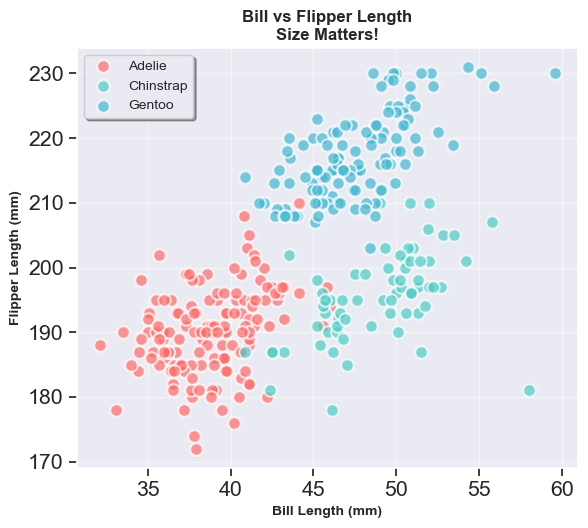

In [ ]:
# 1. Main scatter plot: Bill Length vs Flipper Length (top-left)

plt.figure(figsize=(22, 12))
ax1 = plt.subplot(2, 3, 1)
for species, color in colors.items():
    species_data = penguins_clean[penguins_clean['species'] == species]
    ax1.scatter(species_data['bill_length_mm'], species_data['flipper_length_mm'], 
               c=color, label=species, s=80, alpha=0.7, edgecolors='white', linewidth=1.5)
ax1.set_xlabel('Bill Length (mm)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Flipper Length (mm)', fontsize=10, fontweight='bold')
ax1.set_title('Bill vs Flipper Length\nSize Matters!', fontsize=12, fontweight='bold')
ax1.legend(frameon=True, fancybox=True, shadow=True, fontsize=10)
ax1.grid(True, alpha=0.5)

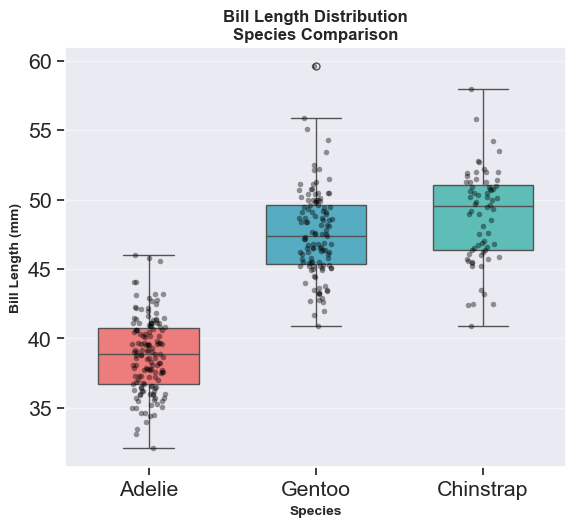

In [ ]:
# 3. Box plot: Bill Length by Species (top-right)

plt.figure(figsize=(22, 12))
ax3 = plt.subplot(2, 3, 3)
sns.boxplot(data=penguins_clean, x='species', y='bill_length_mm', 
            palette=colors, ax=ax3, width=0.6, fliersize=5)
sns.stripplot(data=penguins_clean, x='species', y='bill_length_mm', 
              color='black', alpha=0.4, size=4, ax=ax3)
ax3.set_xlabel('Species', fontsize=10, fontweight='bold')
ax3.set_ylabel('Bill Length (mm)', fontsize=10, fontweight='bold')
ax3.set_title('Bill Length Distribution\nSpecies Comparison', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.5, axis='y')

In [ ]:
# Define species comparisons
species_pairs = [('Adelie', 'Chinstrap'), ('Adelie', 'Gentoo'), ('Chinstrap', 'Gentoo')]
metrics = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
metric_labels = ['Bill Length (mm)', 'Bill Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']

In [ ]:
# Calculate effect sizes (Cohen's d) and confidence intervals
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size and 95% CI"""
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    
    # Pooled standard deviation
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    # Cohen's d
    cohens_d = (mean1 - mean2) / pooled_sd
    
    # Standard error and confidence interval
    se = np.sqrt((n1 + n2) / (n1 * n2) + (cohens_d**2) / (2 * (n1 + n2)))
    ci_lower = cohens_d - 1.96 * se
    ci_upper = cohens_d + 1.96 * se
    
    return cohens_d, ci_lower, ci_upper

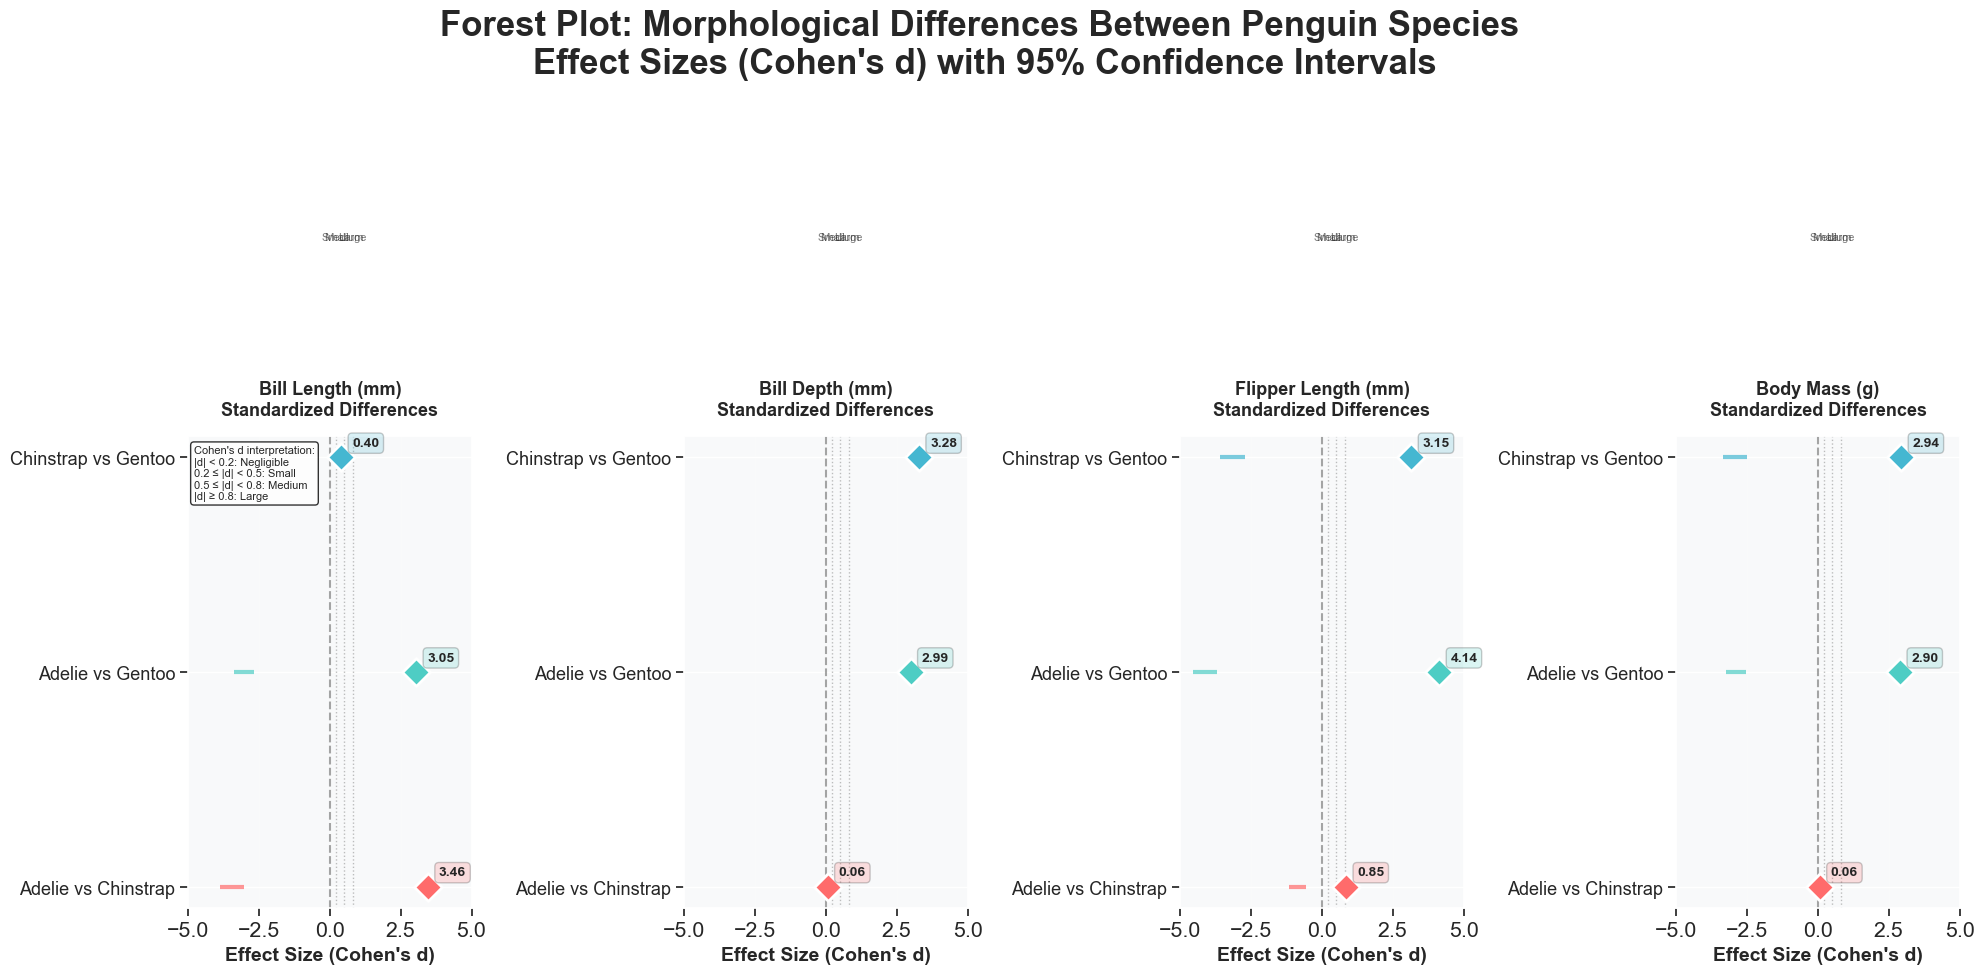

In [ ]:
# Create figure for forest plot
fig, axes = plt.subplots(1, 4, figsize=(20, 10))
fig.suptitle('Forest Plot: Morphological Differences Between Penguin Species \nEffect Sizes (Cohen\'s d) with 95% Confidence Intervals', 
             fontsize=25, fontweight='bold', y=0.98)

# Define beautiful colors for each comparison
comparison_colors = {
    'Adelie vs Chinstrap': '#FF6B6B',
    'Adelie vs Gentoo': '#4ECDC4', 
    'Chinstrap vs Gentoo': '#45B7D1'
}

# Create forest plots for each metric
for idx, (metric, metric_label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]
    
    # Store effect sizes and CIs
    effect_sizes = []
    ci_lower_list = []
    ci_upper_list = []
    labels = []
    colors_list = []
    
    for species1, species2 in species_pairs:
        group1 = penguins_clean[penguins_clean['species'] == species1][metric].values
        group2 = penguins_clean[penguins_clean['species'] == species2][metric].values
        
        d, ci_low, ci_high = cohens_d(group1, group2)
        
        # Determine direction (which species is larger)
        mean1, mean2 = np.mean(group1), np.mean(group2)
        if mean1 > mean2:
            label = f"{species1} > {species2}"
        else:
            label = f"{species2} > {species1}"
            d = -d  # Reverse direction for consistent interpretation
        
        effect_sizes.append(d)
        ci_lower_list.append(ci_low)
        ci_upper_list.append(ci_high)
        labels.append(f"{species1} vs {species2}")
        colors_list.append(comparison_colors[f"{species1} vs {species2}"])
    
    # Create forest plot
    y_pos = np.arange(len(labels))

        # Plot points and error bars
    for i, (y, d, ci_low, ci_high, color) in enumerate(zip(y_pos, effect_sizes, 
                                                           ci_lower_list, ci_upper_list, 
                                                           colors_list)):
        # Main point
        ax.scatter(d, y, s=200, c=color, zorder=3, 
                  edgecolors='white', linewidth=2, marker='D')
        
        # Confidence interval line
        ax.hlines(y, ci_low, ci_high, colors=color, linewidth=3, alpha=0.7, zorder=2)
        
        # Add annotation for effect size value
        ax.annotate(f'{d:.2f}', xy=(d, y), xytext=(8, 8),
                   textcoords='offset points', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.2))

    # Add vertical line at 0 (no effect)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
    
    # Add vertical line at small/medium/large effect thresholds (Cohen's conventions)
    ax.axvline(x=0.2, color='gray', linestyle=':', linewidth=1, alpha=0.5, zorder=1)
    ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5, zorder=1)
    ax.axvline(x=0.8, color='gray', linestyle=':', linewidth=1, alpha=0.5, zorder=1)
    
    # Add effect size labels at the top
    ax.text(0.2, len(labels), 'Small', ha='center', va='bottom', fontsize=6, alpha=0.6)
    ax.text(0.5, len(labels), 'Medium', ha='center', va='bottom', fontsize=6, alpha=0.6)
    ax.text(0.8, len(labels), 'Large', ha='center', va='bottom', fontsize=8, alpha=0.6)
    
    # Customize the plot
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=13)
    ax.set_xlabel('Effect Size (Cohen\'s d)', fontsize=14, fontweight='bold')
    ax.set_title(f'{metric_label}\nStandardized Differences', fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.2, axis='x')
    ax.set_xlim(-5, 5)
    
    # Add a background color
    ax.set_facecolor('#F8F9FA')
    
    # Add interpretation text
    if idx == 0:
        ax.text(0.02, 0.98, 'Cohen\'s d interpretation:\n|d| < 0.2: Negligible\n0.2 ≤ |d| < 0.5: Small\n0.5 ≤ |d| < 0.8: Medium\n|d| ≥ 0.8: Large', 
                transform=ax.transAxes, fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
# Define species comparisons and metrics
species_pairs = [('Adelie', 'Chinstrap'), ('Adelie', 'Gentoo'), ('Chinstrap', 'Gentoo')]
metrics = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
metric_labels = ['Bill Length (mm)', 'Bill Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']

In [ ]:
# Calculate Cohen's d and confidence intervals
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size and 95% CI"""
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    
    # Pooled standard deviation
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    # Cohen's d
    cohens_d = (mean1 - mean2) / pooled_sd
    
    # Standard error and confidence interval
    se = np.sqrt((n1 + n2) / (n1 * n2) + (cohens_d**2) / (2 * (n1 + n2)))
    ci_lower = cohens_d - 1.96 * se
    ci_upper = cohens_d + 1.96 * se
    
    return cohens_d, ci_lower, ci_upper


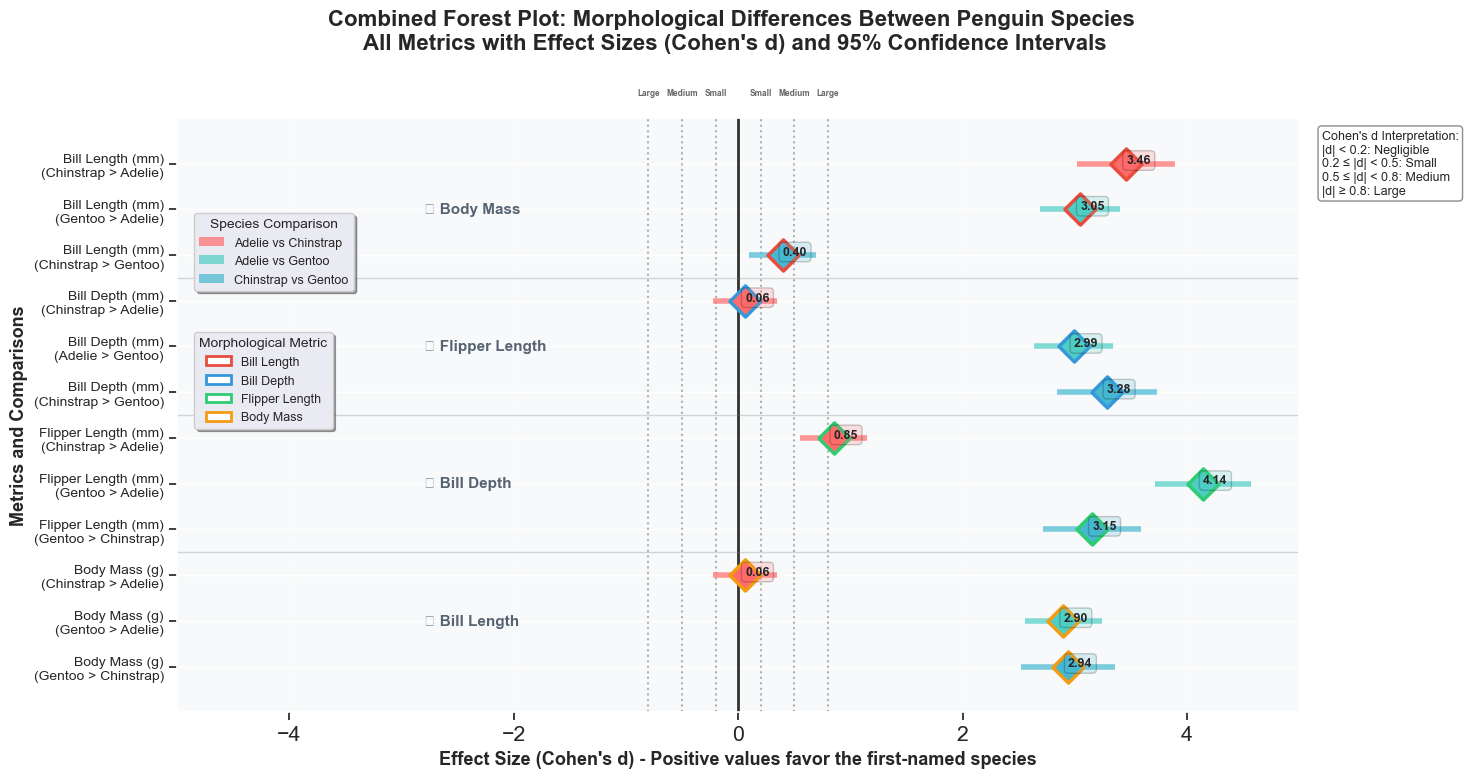

In [ ]:
# Create a SINGLE combined forest plot
fig, ax = plt.subplots(figsize=(15, 8))
fig.suptitle('Combined Forest Plot: Morphological Differences Between Penguin Species \nAll Metrics with Effect Sizes (Cohen\'s d) and 95% Confidence Intervals', 
             fontsize=16, fontweight='bold', y=0.98)

# Define beautiful colors for each comparison
comparison_colors = {
    'Adelie vs Chinstrap': '#FF6B6B',
    'Adelie vs Gentoo': '#4ECDC4', 
    'Chinstrap vs Gentoo': '#45B7D1'
}

# Create a color map for metrics (for visual differentiation)
metric_colors = {
    'Bill Length (mm)': '#E74C3C',
    'Bill Depth (mm)': '#3498DB',
    'Flipper Length (mm)': '#2ECC71',
    'Body Mass (g)': '#F39C12'
}

# Prepare data for combined plot
all_effect_sizes = []
all_ci_lower = []
all_ci_upper = []
all_labels = []
all_colors = []
all_metrics = []

for metric, metric_label in zip(metrics, metric_labels):
    for species1, species2 in species_pairs:
        group1 = penguins_clean[penguins_clean['species'] == species1][metric].values
        group2 = penguins_clean[penguins_clean['species'] == species2][metric].values
        
        d, ci_low, ci_high = cohens_d(group1, group2)
        
        # Determine direction (which species is larger)
        mean1, mean2 = np.mean(group1), np.mean(group2)
        if mean1 > mean2:
            direction = f"{species1} > {species2}"
        else:
            direction = f"{species2} > {species1}"
            d = -d
            ci_low, ci_high = -ci_high, -ci_low
        
        # Create label with metric and direction
        label = f"{metric_label}\n({direction})"
        
        all_labels.append(label)
        all_effect_sizes.append(d)
        all_ci_lower.append(ci_low)
        all_ci_upper.append(ci_high)
        all_colors.append(comparison_colors[f"{species1} vs {species2}"])
        all_metrics.append(metric_label)

# Create y positions (reversed so first metric appears at top)
y_pos = np.arange(len(all_labels))[::-1]

# Plot each effect size with its confidence interval
for i, (y, d, ci_low, ci_high, color, metric) in enumerate(zip(y_pos, all_effect_sizes, 
                                                                all_ci_lower, all_ci_upper, 
                                                                all_colors, all_metrics)):
    # Main point with metric-based edge color
    ax.scatter(d, y, s=250, c=color, zorder=3, 
              edgecolors=metric_colors[metric], linewidth=2.5, marker='D')
    
    # Confidence interval line
    ax.hlines(y, ci_low, ci_high, colors=color, linewidth=4, alpha=0.7, zorder=2)
    
    # Add annotation for effect size value
    offset_x = 0.08 if d >= 0 else -0.35
    ax.annotate(f'{d:.2f}', xy=(d, y), xytext=(offset_x, 0),
               textcoords='offset points', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.2))

# Add vertical reference lines
ax.axvline(x=0, color='black', linestyle='-', linewidth=2, alpha=0.8, zorder=1)
ax.axvline(x=0.2, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
ax.axvline(x=0.8, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
ax.axvline(x=-0.2, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
ax.axvline(x=-0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
ax.axvline(x=-0.8, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)

# Add effect size labels at the top
ax.text(0.2, len(all_labels) + 0.5, 'Small', ha='center', fontsize=6, alpha=0.7, fontweight='bold')
ax.text(0.5, len(all_labels) + 0.5, 'Medium', ha='center', fontsize=6, alpha=0.7, fontweight='bold')
ax.text(0.8, len(all_labels) + 0.5, 'Large', ha='center', fontsize=6, alpha=0.7, fontweight='bold')
ax.text(-0.2, len(all_labels) + 0.5, 'Small', ha='center', fontsize=6, alpha=0.7, fontweight='bold')
ax.text(-0.5, len(all_labels) + 0.5, 'Medium', ha='center', fontsize=6, alpha=0.7, fontweight='bold')
ax.text(-0.8, len(all_labels) + 0.5, 'Large', ha='center', fontsize=6, alpha=0.7, fontweight='bold')

# Customize the plot
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=10)
ax.set_xlabel('Effect Size (Cohen\'s d) - Positive values favor the first-named species', 
              fontsize=13, fontweight='bold')
ax.set_ylabel('Metrics and Comparisons', fontsize=13, fontweight='bold')
ax.set_xlim(-5, 5)
ax.set_ylim(-1, len(all_labels))

# Add grid
ax.grid(True, alpha=0.2, axis='x')
ax.set_facecolor('#F8F9FA')

# Add interpretation text box
interpretation_text = "Cohen's d Interpretation:\n|d| < 0.2: Negligible\n0.2 ≤ |d| < 0.5: Small\n0.5 ≤ |d| < 0.8: Medium\n|d| ≥ 0.8: Large"
ax.text(1.02, 0.98, interpretation_text, transform=ax.transAxes, 
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# Add legends
from matplotlib.patches import Patch

# Legend for comparison types
legend_elements1 = [
    Patch(facecolor='#FF6B6B', alpha=0.7, label='Adelie vs Chinstrap'),
    Patch(facecolor='#4ECDC4', alpha=0.7, label='Adelie vs Gentoo'),
    Patch(facecolor='#45B7D1', alpha=0.7, label='Chinstrap vs Gentoo')
]
legend1 = ax.legend(handles=legend_elements1, loc='upper left', 
                    frameon=True, fancybox=True, shadow=True, 
                    title='Species Comparison', fontsize=9,
                    title_fontsize=10, bbox_to_anchor=(0.01, 0.85))

# Legend for metrics (using the edge colors)
legend_elements2 = [
    Patch(facecolor='white', edgecolor='#E74C3C', linewidth=2, label='Bill Length'),
    Patch(facecolor='white', edgecolor='#3498DB', linewidth=2, label='Bill Depth'),
    Patch(facecolor='white', edgecolor='#2ECC71', linewidth=2, label='Flipper Length'),
    Patch(facecolor='white', edgecolor='#F39C12', linewidth=2, label='Body Mass')
]
legend2 = ax.legend(handles=legend_elements2, loc='upper left', 
                    frameon=True, fancybox=True, shadow=True, 
                    title='Morphological Metric', fontsize=9,
                    title_fontsize=10, bbox_to_anchor=(0.01, 0.65))

# Add second legend
ax.add_artist(legend1)

# Add horizontal separator lines between metrics
for i in range(3):  # 4 metrics, so 3 separators
    separator_pos = (i + 1) * 3 - 0.5
    ax.axhline(y=separator_pos, color='gray', linestyle='-', linewidth=1, alpha=0.3)

# Add metric group labels
metric_positions = [1, 4, 7, 10]  # Center positions for each metric group
metric_names = ['Bill Length', 'Bill Depth', 'Flipper Length', 'Body Mass']
for pos, name in zip(metric_positions, metric_names):
    ax.text(-2.8, pos, f'▸ {name}', fontsize=11, fontweight='bold', 
            va='center', color='#2C3E50', alpha=0.8)

plt.tight_layout()
plt.show()